In [1]:
# Librerías base
import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Modelos
from sklearn.linear_model import LogisticRegression

In [4]:
# Cargar dataset
data_path = "../data/raw/MalBehavD-V1-dataset.csv"

df = pd.read_csv(data_path)

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (2570, 177)


,sha256,labels,0,1,2,3,4,5,6,7,...,Unnamed: 167,Unnamed: 168,Unnamed: 169,Unnamed: 170,Unnamed: 171,Unnamed: 172,Unnamed: 173,Unnamed: 174,Unnamed: 175,Unnamed: 176
0,5c18291c481a192ed5003084dab2d8a117fd3736359218...,0,LdrUnloadDll,CoUninitialize,NtQueryKey,NtDuplicateObject,GetShortPathNameW,GetSystemInfo,IsDebuggerPresent,GetSystemWindowsDirectoryW,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,4683faf3da550ffb594cf5513c4cbb34f64df85f27fd1c...,0,NtOpenMutant,GetForegroundWindow,NtQueryKey,DrawTextExW,NtSetInformationFile,RegQueryValueExA,LdrGetProcedureAddress,CoUninitialize,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,9a0aea1c7290031d7c3429d0e921f107282cc6eab854ee...,0,GetForegroundWindow,DrawTextExW,GetSystemInfo,IsDebuggerPresent,GetSystemWindowsDirectoryW,NtQueryValueKey,RegCloseKey,GetFileAttributesW,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,e0f3e4d5f50afd9c31e51dd9941c5a52d57c7c524f5d11...,0,NtQueryValueKey,LdrUnloadDll,GlobalMemoryStatus,WriteConsoleA,NtOpenKey,LdrGetProcedureAddress,NtTerminateProcess,NtClose,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,ec2b6d29992f13e74015ff0b129150b4afae15c593e4b7...,0,LdrUnloadDll,GetSystemTimeAsFileTime,NtOpenKey,WSAStartup,SetUnhandledExceptionFilter,NtTerminateProcess,NtClose,NtAllocateVirtualMemory,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# Información del dataset

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2570 entries, 0 to 2569
Columns: 177 entries, sha256 to Unnamed: 176
dtypes: int64(1), object(176)
memory usage: 3.5+ MB


In [ ]:
# Distribución de clases

df["labels"].value_counts()

labels
0    1285
1    1285
Name: count, dtype: int64

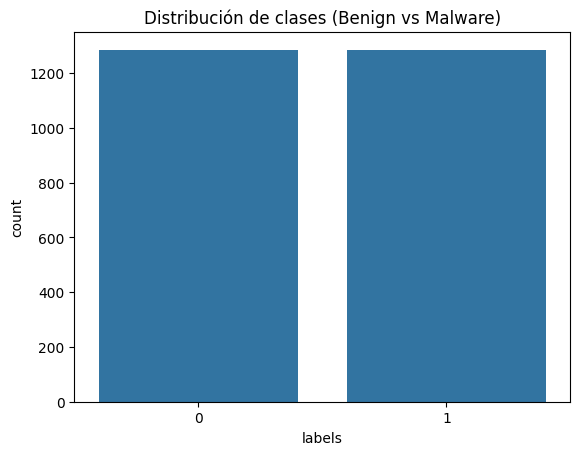

In [7]:
# Visualizar distribución

sns.countplot(x="labels", data=df)
plt.title("Distribución de clases (Benign vs Malware)")
plt.show()

In [8]:
# Convertir columnas de APIs en una secuencia de texto

api_columns = df.columns[2:]

df["sequence"] = df[api_columns].apply(
    lambda row: " ".join(row.dropna().astype(str)),
    axis=1
)

df[["labels", "sequence"]].head()

,labels,sequence
0,0,LdrUnloadDll CoUninitialize NtQueryKey NtDupli...
1,0,NtOpenMutant GetForegroundWindow NtQueryKey Dr...
2,0,GetForegroundWindow DrawTextExW GetSystemInfo ...
3,0,NtQueryValueKey LdrUnloadDll GlobalMemoryStatu...
4,0,LdrUnloadDll GetSystemTimeAsFileTime NtOpenKey...


In [9]:
# Dividir dataset en entrenamiento y prueba

X = df["sequence"]
y = df["labels"]

# Train / Test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    stratify=y,
    random_state=42
)

print("Train size:", len(X_train))
print("Test size:", len(X_test))

Train size: 1799
Test size: 771


In [10]:
# Vectorización

# Convertir texto a vectores numéricos
vectorizer = TfidfVectorizer(
    max_features=5000
)

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

print("Train vector shape:", X_train_vec.shape)

Train vector shape: (1799, 286)


In [11]:
# Entrenar modelo

model = LogisticRegression(max_iter=1000)

model.fit(X_train_vec, y_train)

LogisticRegression(max_iter=1000)

In [ ]:
# Predicciones

y_pred = model.predict(X_test_vec)

In [ ]:
# Accuracy

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9455252918287937


In [ ]:
# Classification report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.94      0.95      0.95       386
           1       0.95      0.94      0.95       385

    accuracy                           0.95       771
   macro avg       0.95      0.95      0.95       771
weighted avg       0.95      0.95      0.95       771



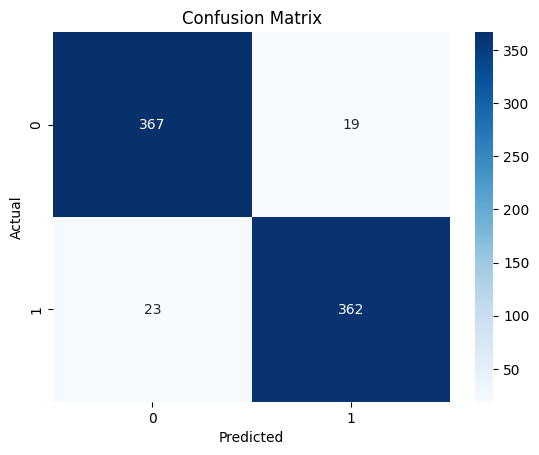

In [15]:
# Confusion Matrix

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()